In [15]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')


# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# KerasNLP pour BERT
import keras_nlp

# Sklearn pour métriques
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Keggle hub pour dataset
import kagglehub

import re
import os


# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"\n📦 TensorFlow version: {tf.__version__}")
print(f"📦 Keras version: {keras.__version__}")
print(f"📦 KerasNLP version: {keras_nlp.__version__}")

⚠️  Aucun GPU détecté - Utilisation du CPU

📦 TensorFlow version: 2.20.0
📦 Keras version: 3.13.2
📦 KerasNLP version: 0.26.0


In [ ]:
print("Récupération des données...")
# Récupérer les données
path = kagglehub.dataset_download("haideradnan77/mental-health-condition-classification")

for f in os.listdir(path):
    df = pd.read_csv(os.path.join(path, f))

print(".. OK")

print("Nombre d'entrées : ", df.shape[0])

df.head()

Récupération des données...
.. OK
Nombre d'entrées :  103488


NameError: name 'status' is not defined

In [17]:
X_train_all, X_test_raw, y_train_all, y_test_raw = train_test_split(df["text"], df["status"], test_size=0.2, random_state=SEED)

# Créer un validation set
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.25, random_state=SEED, stratify=y_train_all
)

print(f"✅ Préparation terminée !")
print(f"\n📊 Répartition finale:")
print(f"   Train: {len(X_train_raw):,} elements")
print(f"   Validation: {len(X_val_raw):,} elements")
print(f"   Test: {len(X_test_raw):,} elements")


✅ Préparation terminée !

📊 Répartition finale:
   Train: 62,092 elements
   Validation: 20,698 elements
   Test: 20,698 elements


In [36]:
statuses = df.groupby("status")

CLASSES_COUNT = len(statuses)
print(f"Nous avons {CLASSES_COUNT} classes:")

for name, group in statuses:
    print("\t", name, len(group))
    for idx, elem in enumerate(group["text"]):
        if idx == 5:
            break
        print(elem)


chart_values = [len(group) for _, group in statuses]
chart_labels = [name for name, _ in statuses]


Nous avons 7 classes:
	 anxiety 17620
"My mind is a never-ending cycle of worry, and even the simplest tasks feel insurmountable."

"I'm consumed by fear and doubt, and every decision feels like a minefield waiting to explode."

"Anxiety has a grip on me, and I'm powerless to break free from its relentless hold."

"My thoughts race like a runaway train, and I can't seem to find a way to slow down and catch my breath."

"I'm trapped in a whirlwind of fear and uncertainty, and I can't seem to find a way to escape."

"My heart pounds in my chest, and my
I'm trapped in a whirlwind of thoughts, unable to focus on anything as my mind races with worst-case scenarios, leaving me feeling helpless and consumed by fear.
"Every moment is a battlefield in my mind. The fear of making a mistake looms large, and my thoughts spiral out of control, leaving me feeling trapped and powerless."
"My mind is a whirlwind of worry and fear, making even the simplest tasks feel insurmountable."
"Every nerve in my

In [19]:
# labels
y_labels = chart_labels

y_train_array = y_train_raw.transform(lambda x: y_labels.index(x))
y_train = tf.keras.utils.to_categorical(y_train_array, num_classes=len(y_labels))

y_val_array = y_val_raw.transform(lambda x: y_labels.index(x))
y_val = tf.keras.utils.to_categorical(y_val_array, num_classes=len(y_labels))

y_test_array = y_test_raw.transform(lambda x: y_labels.index(x))
y_test = tf.keras.utils.to_categorical(y_test_array, num_classes=len(y_labels))

print(f"\n Dimensions des données :")
print(f"  y (output) : {y_train.shape} - (nombre_sequences, classes)")



 Dimensions des données :
  y (output) : (62092, 7) - (nombre_sequences, classes)


In [20]:
class LivePlotCallback(Callback):
    """
    Callback pour visualiser les métriques d'entraînement en temps réel.
    """
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.accuracy = []
        self.val_accuracy = []
        
    def on_epoch_end(self, epoch, logs=None):
        # Enregistrement des métriques
        self.epochs.append(epoch + 1)
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.accuracy.append(logs.get('accuracy'))
        self.val_accuracy.append(logs.get('val_accuracy'))
        
        # Effacement et redessin
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Graphique de la loss
        ax1.plot(self.epochs, self.loss, 'o-', label='Loss d\'entraînement',
                linewidth=2.5, markersize=8, color='#E63946')
        ax1.plot(self.epochs, self.val_loss, 's-', label='Loss de validation',
                linewidth=2.5, markersize=8, color='#F77F00')
        ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12, fontweight='bold')
        ax1.set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11, loc='upper right')
        ax1.grid(alpha=0.3)
        
        # Graphique de l'accuracy
        ax2.plot(self.epochs, self.accuracy, 'o-', label='Accuracy d\'entraînement',
                linewidth=2.5, markersize=8, color='#06AED5')
        ax2.plot(self.epochs, self.val_accuracy, 's-', label='Accuracy de validation',
                linewidth=2.5, markersize=8, color='#073B4C')
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11, loc='lower right')
        ax2.grid(alpha=0.3)
        ax2.set_ylim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        # Affichage textuel
        print(f"\n{'='*70}")
        print(f"Epoch {epoch + 1}/{self.params['epochs']}")
        print(f"{'='*70}")
        print(f"Loss d'entraînement : {logs.get('loss'):.4f}")
        print(f"Accuracy d'entraînement : {logs.get('accuracy'):.4f} ({logs.get('accuracy')*100:.2f}%)")
        print(f"\nLoss de validation : {logs.get('val_loss'):.4f}")
        print(f"Accuracy de validation : {logs.get('val_accuracy'):.4f} ({logs.get('val_accuracy')*100:.2f}%)")
        print(f"{'='*70}")

print("✅ Callback de visualisation créé")

✅ Callback de visualisation créé


In [21]:
# Configuration
MAX_WORDS = 10000
MAX_LEN = 250

BATCH_SIZE=32
EPOCH_TL=30
EPOCH_FT=100

BERT_MODEL_NAME= "bert_medium_en_uncased"#, "bert_small_en_uncased","bert_medium_en_uncased"

In [22]:
# Charger le préprocesseur BERT de KerasNLP
print("📥 Chargement du preprocesseur BERT...\n")

# Utiliser le preprocesseur BERT pré-entraîné
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    BERT_MODEL_NAME,
    sequence_length=128
)

print("✅ Preprocesseur chargé !")
print(f"\nVocabulaire: {preprocessor.tokenizer.vocabulary_size():,} tokens")
print(f"Longueur de séquence: 128")

📥 Chargement du preprocesseur BERT...

✅ Preprocesseur chargé !

Vocabulaire: 30,522 tokens
Longueur de séquence: 128


In [23]:
def compile_model(model, learning_rate=1e-5):
        # Compiler
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
    )

    return model

def create_frozen_bert_model(learning_rate=1e-5, dropout_rate=0.1, dense_units_count=128, dense_layers=1):
    """
    Crée un modèle BERT avec les poids gelés (Feature Extraction).
    """
    # Charger BERT pré-entraîné
    bert_backbone = keras_nlp.models.BertBackbone.from_preset(
        BERT_MODEL_NAME,  # Version légère
        trainable=False  # GELÉ
    )
    
    # Input
    inputs = {
        "token_ids": layers.Input(shape=(128,), dtype=tf.int32, name="token_ids"),
        "segment_ids": layers.Input(shape=(128,), dtype=tf.int32, name="segment_ids"),
        "padding_mask": layers.Input(shape=(128,), dtype=tf.int32, name="padding_mask"),
    }
    
    # BERT Encoder
    bert_output = bert_backbone(inputs)["sequence_output"]
    
    # Prendre le [CLS] token (première position)
    cls_token = bert_output[:, 0, :]
    
    # Couches de classification
    x = layers.Dropout(dropout_rate)(cls_token)
    for _ in range(0, dense_layers):
        x = layers.Dense(dense_units_count, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(CLASSES_COUNT, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs, output)
    
    # Compiler
    model = compile_model(model, learning_rate)
    return model, bert_backbone


# Créer le modèle
print("🔨 Création du modèle BERT (Feature Extraction)...\n")
bert_frozen_model, bert_backbone = create_frozen_bert_model()

print("✅ Modèle BERT (frozen) créé !\n")
bert_frozen_model.summary()

🔨 Création du modèle BERT (Feature Extraction)...

✅ Modèle BERT (frozen) créé !



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 512),     │ 41,373,184 │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 512)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 512)       │          0 │ bert_backbone[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 512)       │          0 │ get_item_3[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,439,751 (158.08 MB)

 Trainable params: 66,567 (260.03 KB)

 Non-trainable params: 41,373,184 (157.83 MB)

In [24]:
# Préprocesser les données
print("🔄 Preprocessing des données avec BERT...\n")

X_train_bert = preprocessor(X_train_raw)
X_val_bert = preprocessor(X_val_raw)
X_test_bert = preprocessor(X_test_raw)

print("✅ Preprocessing terminé !")

🔄 Preprocessing des données avec BERT...

✅ Preprocessing terminé !


In [25]:
live_plot = LivePlotCallback()
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_on_plateau = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

print("Callbacks ok!")

Callbacks ok!


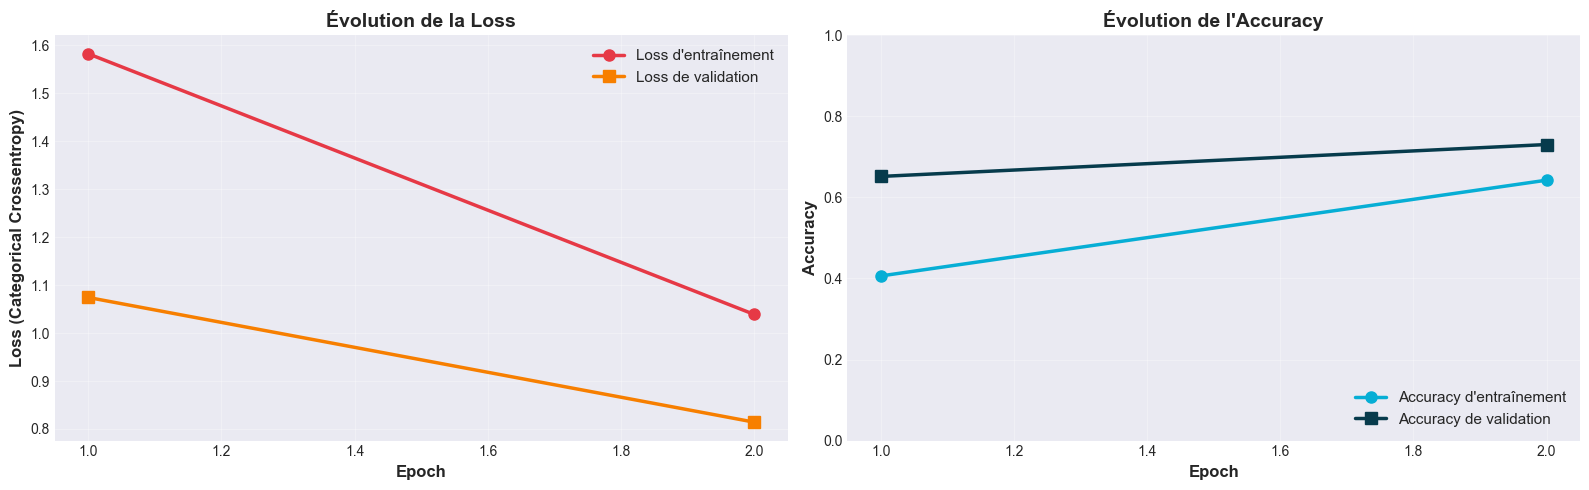


Epoch 2/30
Loss d'entraînement : 1.0387
Accuracy d'entraînement : 0.6426 (64.26%)

Loss de validation : 0.8142
Accuracy de validation : 0.7306 (73.06%)
1941/1941 ━━━━━━━━━━━━━━━━━━━━ 3344s 2s/step - accuracy: 0.6426 - loss: 1.0387 - top2_accuracy: 0.8258 - val_accuracy: 0.7306 - val_loss: 0.8142 - val_top2_accuracy: 0.8739 - learning_rate: 1.0000e-05
Epoch 3/30
1668/1941 ━━━━━━━━━━━━━━━━━━━━ 5:49 1s/step - accuracy: 0.6980 - loss: 0.8882 - top2_accuracy: 0.8601

KeyboardInterrupt: 

In [26]:
# Entraînement
print("\n🚀 Entraînement BERT (Feature Extraction)...\n")

history_bert_frozen = bert_frozen_model.fit(
    X_train_bert,
    y_train,
    validation_data=(X_val_bert, y_val),
    epochs=EPOCH_TL,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[reduce_on_plateau, early_stop, checkpoint, live_plot],
)

print("\n Entraînement BERT (frozen) terminé !")
print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

best_val_acc = max(history_bert_frozen.history['val_accuracy'])
best_epoch = history_bert_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

if best_val_acc < 0.70:
    print(f"\n  Accuracy de {best_val_acc*100:.1f}% est en dessous de 70%")
    print("   Le modèle pourrait bénéficier de plus d'entraînement.")
elif best_val_acc < 0.80:
    print(f"\n Bon résultat : {best_val_acc*100:.1f}%")
else:
    print(f"\n Excellent ! Accuracy de {best_val_acc*100:.1f}%")

In [ ]:
X_test_bert = preprocessor(X_test_raw)
y_test_idx = np.argmax(y_test, axis=1)

y_pred_bert = bert_frozen_model.predict(X_test_bert, verbose=0)

y_pred_bert_idx = np.argmax(y_pred_bert, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_bert_idx, target_names=y_labels))


In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_bert_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - BERT Features Extraction', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

preprocessed_phrases = preprocessor(phrases)
pred = bert_frozen_model.predict(preprocessed_phrases)
for idx, p in enumerate(pred):
    print(phrases[idx])
    print("It is", y_labels[np.argmax(p)])

In [ ]:
# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = bert_frozen_model.evaluate((X_val_bert, y_val), verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

bert_backbone.trainable = True

trainable_from = 10
for idx, layer in enumerate(bert_backbone.layers):
    if idx < trainable_from:
        layer.trainable = False
    else:
        layer.trainable = True

LR = 1e-5
bert_ft_model = compile_model(bert_frozen_model, LR)

bert_ft_model.summary()

print("\n🔍 Vérification immédiate :")
results_after_compile = bert_ft_model.evaluate((X_val_bert, y_val), verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

In [ ]:
model_finetuned = model_frozen

print(f"✅ Modèle recompilé avec LR = {FINE_TUNE_LR}")
print("\n💡 Le modèle va continuer depuis les poids déjà appris.")

# Vérification immédiate
print("\n🔍 Vérification immédiate :")
results_after_compile = model_finetuned.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

In [ ]:
# Entraînement
print("\nEntraînement BERT (Fine Tuning)...\n")

history_bert_ft = bert_ft_model.fit(
    X_train_bert,
    y_train,
    validation_data=(X_val_bert, y_val),
    epochs=EPOCH_FT,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[reduce_on_plateau, early_stop, live_plot, checkpoint],
)

print("\nEntraînement BERT (fine tuned) terminé !")

In [ ]:
X_test_bert = preprocessor(X_test_raw)
y_test_idx = np.argmax(y_test, axis=1)

y_pred_bert = bert_ft_model.predict(X_test_bert, verbose=0)

y_pred_bert_idx = np.argmax(y_pred_bert, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_bert_idx, target_names=y_labels))

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_bert_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - BERT Fine Tuned', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

preprocessed_phrases = preprocessor(phrases)
pred = bert_ft_model.predict(preprocessed_phrases)
for idx, p in enumerate(pred):
    print(phrases[idx])
    print("It is", y_labels[np.argmax(p)])